## IMPORT

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, roc_auc_score, 
                             roc_curve, auc)
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.utils.class_weight import compute_sample_weight
import time
from time import sleep, time as current_time
import warnings
warnings.filterwarnings('ignore')


## SETUP

In [10]:
# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 80)
print("MACHINE LEARNING ASSIGNMENT - POKER HAND CLASSIFICATION")
print("=" * 80)


MACHINE LEARNING ASSIGNMENT - POKER HAND CLASSIFICATION


## DATA LOADING

This section is responsible for **loading the "Poker Hand Dataset"** directly from the UCI Machine Learning Repository.

The dataset is fundamental for our comparative analysis of classifiers, given its **multiclass nature (10 classes)** and the known **strong class imbalance** between classes, which will test the robustness of the chosen models.

In [ ]:
print("\n" + "=" * 80)
print("PART 1: DATA LOADING")
print("=" * 80)

from ucimlrepo import fetch_ucirepo

# Loads the "Poker Hand" dataset using ID 158
poker_hand = fetch_ucirepo(id=158)

X = poker_hand.data.features
y = poker_hand.data.targets

print(f"\nDataset loaded successfully!")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

print("\n--- Dataset Information ---")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"\nFeature names: {list(X.columns)}")

# Convert target to 1D array if needed
if isinstance(y, pd.DataFrame):
    y = y.values.ravel()

print(f"\nTarget variable (Poker Hand classes):")
print(f"Unique classes: {np.unique(y)}")
print(f"Number of classes: {len(np.unique(y))}")

# Calculating and printing the class distribution to highlight the imbalance
print("\n--- Class Distribution ---")
unique, counts = np.unique(y, return_counts=True)
class_dist = pd.DataFrame({'Class': unique, 'Count': counts, 'Percentage': counts/len(y)*100})
print(class_dist)



PART 1: DATA LOADING

Dataset loaded successfully!
Features shape: (1025010, 10)
Target shape: (1025010, 1)

--- Dataset Information ---
Number of samples: 1025010
Number of features: 10

Feature names: ['S1', 'C1', 'S2', 'C2', 'S3', 'C3', 'S4', 'C4', 'S5', 'C5']

Target variable (Poker Hand classes):
Unique classes: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 10

--- Class Distribution ---
   Class   Count  Percentage
0      0  513702   50.116779
1      1  433097   42.252954
2      2   48828    4.763661
3      3   21634    2.110614
4      4    3978    0.388094
5      5    2050    0.199998
6      6    1460    0.142438
7      7     236    0.023024
8      8      17    0.001659
9      9       8    0.000780


## DATA PREPROCESSING

Preprocessing is crucial for preparing data for Machine Learning algorithms. For this problem:

1.  **Absence of Missing/Noisy Data**: We verify the integrity of the dataset.
2.  **Stratified Splitting**: Data is divided into Training (70%), Validation (15%), and Test (15%) sets. **Stratification** is mandatory to preserve the heavily imbalanced distribution of the 10 classes in each subset.
3.  **Normalization (StandardScaler)**: Features are standardized (mean=0, standard deviation=1). This is essential for distance- or gradient-based models (like Softmax Regression) to ensure efficient convergence and fair results.

In [ ]:
print("\n" + "=" * 80)
print("PART 2: DATA PREPROCESSING")
print("=" * 80)

# Check for missing values - The UCI dataset has no missing values
print(f"\nMissing values per feature:")
print(X.isnull().sum())
print(f"\nMissing values in target: {pd.isnull(y).sum()}")

# Basic statistics
print("\n--- Feature Statistics ---")
print(X.describe())

# Split data: 70% train, 15% validation, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=RANDOM_STATE, stratify=y_temp
)  # 0.176 * 0.85 ≈ 0.15 of total

print(f"\n--- Data Split ---")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/X.shape[0]*100:.1f}%)")

# Standardization scales features, improving the performance of gradient-based models.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\n--- Feature Scaling Applied ---")
print("StandardScaler fitted on training data and applied to all sets")


PART 2: DATA PREPROCESSING

Missing values per feature:
S1    0
C1    0
S2    0
C2    0
S3    0
C3    0
S4    0
C4    0
S5    0
C5    0
dtype: int64

Missing values in target: 0

--- Feature Statistics ---
                 S1            C1            S2            C2            S3  \
count  1.025010e+06  1.025010e+06  1.025010e+06  1.025010e+06  1.025010e+06   
mean   2.500695e+00  6.997861e+00  2.499841e+00  7.006295e+00  2.501100e+00   
std    1.117737e+00  3.743529e+00  1.118646e+00  3.744054e+00  1.118345e+00   
min    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   
25%    2.000000e+00  4.000000e+00  1.000000e+00  4.000000e+00  1.000000e+00   
50%    3.000000e+00  7.000000e+00  2.000000e+00  7.000000e+00  3.000000e+00   
75%    3.000000e+00  1.000000e+01  4.000000e+00  1.000000e+01  4.000000e+00   
max    4.000000e+00  1.300000e+01  4.000000e+00  1.300000e+01  4.000000e+00   

                 C3            S4            C4            S5            C5  
cou

## MODEL IMPLEMENTATION AND TRAINING

This section implements the four chosen classification models: Naive Bayes, Softmax Regression, Decision Tree, and Random Forest.

For each model, **Grid Search with Cross-Validation (Stratified K-Fold)** is performed on the training set. The primary goal of the tuning is to **maximize the Weighted F1 Score**, a more reliable metric compared to simple Accuracy in the presence of strong class imbalance.

In [ ]:
print("\n" + "=" * 80)
print("PART 3: MODEL TRAINING WITH CROSS-VALIDATION")
print("=" * 80)

results = {}
trained_models = {}

# We use Stratified K-Fold (n_splits=5) to preserve class distribution during CV
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


PART 3: MODEL TRAINING WITH CROSS-VALIDATION


##  1. NAIVE BAYES (Gaussian)

In [ ]:
print("\n" + "-" * 80)
print("1. NAIVE BAYES (GAUSSIAN)")
print("-" * 80)

start_time = time.time()

# Note: Naive Bayes doesn't support class_weight parameter
# We'll use sample_weight instead for balancing
from sklearn.utils.class_weight import compute_sample_weight

# Compute sample weights for balancing
sample_weights = compute_sample_weight('balanced', y_train)

# Hyperparameter tuning: exploring the variance smoothing parameter
nb_params = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

nb = GaussianNB()
# We use 'accuracy' as the scoring metric in GridSearch, but F1-weighted will be the key comparative metric in the report
nb_grid = GridSearchCV(nb, nb_params, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
nb_grid.fit(X_train_scaled, y_train, sample_weight=sample_weights)

best_nb = nb_grid.best_estimator_
training_time = time.time() - start_time

print(f"Best parameters: {nb_grid.best_params_}")
print(f"Best CV score: {nb_grid.best_score_:.4f}")
print(f"Training time: {training_time:.2f} seconds")

# Validation performance
y_val_pred_nb = best_nb.predict(X_val_scaled)
val_accuracy_nb = accuracy_score(y_val, y_val_pred_nb)
print(f"Validation accuracy: {val_accuracy_nb:.4f}")

trained_models['Naive Bayes'] = best_nb
results['Naive Bayes'] = {
    'model': best_nb,
    'train_score': nb_grid.best_score_,
    'val_accuracy': val_accuracy_nb,
    'training_time': training_time,
    'y_val_pred': y_val_pred_nb
}


--------------------------------------------------------------------------------
1. NAIVE BAYES (GAUSSIAN)
--------------------------------------------------------------------------------
Best parameters: {'var_smoothing': 1e-09}
Best CV score: 0.1067
Training time: 1.59 seconds
Validation accuracy: 0.0131


## 2. SOFTMAX REGRESSION (Multinomial Logistic Regression)

In [18]:
print("\n" + "-" * 80)
print("2. SOFTMAX REGRESSION (MULTINOMIAL LOGISTIC REGRESSION)")
print("-" * 80)

start_time = time.time()

# Hyperparameter tuning with class balancing
softmax_params = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'saga'],
    'class_weight': ['balanced']  # Handle imbalanced classes
}

softmax = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=RANDOM_STATE)
softmax_grid = GridSearchCV(softmax, softmax_params, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
softmax_grid.fit(X_train_scaled, y_train)

best_softmax = softmax_grid.best_estimator_
training_time = time.time() - start_time

print(f"Best parameters: {softmax_grid.best_params_}")
print(f"Best CV score: {softmax_grid.best_score_:.4f}")
print(f"Training time: {training_time:.2f} seconds")

# Validation performance
y_val_pred_softmax = best_softmax.predict(X_val_scaled)
val_accuracy_softmax = accuracy_score(y_val, y_val_pred_softmax)
print(f"Validation accuracy: {val_accuracy_softmax:.4f}")

trained_models['Softmax Regression'] = best_softmax
results['Softmax Regression'] = {
    'model': best_softmax,
    'train_score': softmax_grid.best_score_,
    'val_accuracy': val_accuracy_softmax,
    'training_time': training_time,
    'y_val_pred': y_val_pred_softmax
}


--------------------------------------------------------------------------------
2. SOFTMAX REGRESSION (MULTINOMIAL LOGISTIC REGRESSION)
--------------------------------------------------------------------------------
Best parameters: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'saga'}
Best CV score: 0.1442
Training time: 1860.53 seconds
Validation accuracy: 0.0931


## 3. DECISION TREE

In [ ]:
print("\n" + "-" * 80)
print("3. DECISION TREE")
print("-" * 80)

start_time = time.time()

# Hyperparameter tuning with class balancing
dt_params = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None]  # Handle imbalanced classes
}

dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
# Note: GridSearch will find the best parameters for Accuracy, 
# but F1-weighted will be the final comparative metric.
dt_grid = GridSearchCV(dt, dt_params, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train_scaled, y_train)

best_dt = dt_grid.best_estimator_
training_time = time.time() - start_time

print(f"Best parameters: {dt_grid.best_params_}")
print(f"Best CV score: {dt_grid.best_score_:.4f}")
print(f"Training time: {training_time:.2f} seconds")

# Validation performance
y_val_pred_dt = best_dt.predict(X_val_scaled)
val_accuracy_dt = accuracy_score(y_val, y_val_pred_dt)
print(f"Validation accuracy: {val_accuracy_dt:.4f}")

trained_models['Decision Tree'] = best_dt
results['Decision Tree'] = {
    'model': best_dt,
    'train_score': dt_grid.best_score_,
    'val_accuracy': val_accuracy_dt,
    'training_time': training_time,
    'y_val_pred': y_val_pred_dt
}



--------------------------------------------------------------------------------
3. DECISION TREE
--------------------------------------------------------------------------------


Python(7791) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(7792) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(7793) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(7794) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(7795) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(7796) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(7797) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(7798) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(7799) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(7800) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Best parameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV score: 0.6512
Training time: 233.68 seconds
Validation accuracy: 0.6643


## 4. RANDOM FOREST

In [14]:
print("\n" + "-" * 80)
print("4. RANDOM FOREST")
print("-" * 80)

start_time = time.time()

# Hyperparameter tuning with class balancing
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced', 'balanced_subsample', None]  # Handle imbalanced classes
}

rf = RandomForestClassifier(random_state=RANDOM_STATE)
rf_grid = GridSearchCV(rf, rf_params, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

best_rf = rf_grid.best_estimator_
training_time = time.time() - start_time

print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best CV score: {rf_grid.best_score_:.4f}")
print(f"Training time: {training_time:.2f} seconds")

# Validation performance
y_val_pred_rf = best_rf.predict(X_val_scaled)
val_accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
print(f"Validation accuracy: {val_accuracy_rf:.4f}")

trained_models['Random Forest'] = best_rf
results['Random Forest'] = {
    'model': best_rf,
    'train_score': rf_grid.best_score_,
    'val_accuracy': val_accuracy_rf,
    'training_time': training_time,
    'y_val_pred': y_val_pred_rf
}

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n--- Feature Importance (Top 5) ---")
print(feature_importance.head())


--------------------------------------------------------------------------------
4. RANDOM FOREST
--------------------------------------------------------------------------------
Best parameters: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.7436
Training time: 12085.77 seconds
Validation accuracy: 0.7549

--- Feature Importance (Top 5) ---
  feature  importance
5      C3    0.140134
7      C4    0.132704
9      C5    0.132684
1      C1    0.129327
3      C2    0.129042


## 5. MODEL EVALUATION

In this phase, the tuned models are evaluated on key metrics using the **Test Set**, ensuring an unbiased measure of their generalization capability on unseen data.

Aggregate metrics (Accuracy, Precision, Recall, F1 Score) are calculated, and importantly, the **Confusion Matrix** is analyzed in detail to understand misclassification patterns, which is crucial given the strong class imbalance.


PART 4: MODEL EVALUATION

EVALUATION: Random Forest

Accuracy:  0.7571
Precision: 0.7452
Recall:    0.7571
F1 Score:  0.7324

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.78      0.92      0.84     77056
           1       0.73      0.68      0.71     64965
           2       0.57      0.06      0.10      7324
           3       0.79      0.13      0.23      3245
           4       0.21      0.09      0.12       597
           5       0.99      0.60      0.75       307
           6       0.42      0.02      0.04       219
           7       0.00      0.00      0.00        35
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         1

    accuracy                           0.76    153752
   macro avg       0.45      0.25      0.28    153752
weighted avg       0.75      0.76      0.73    153752



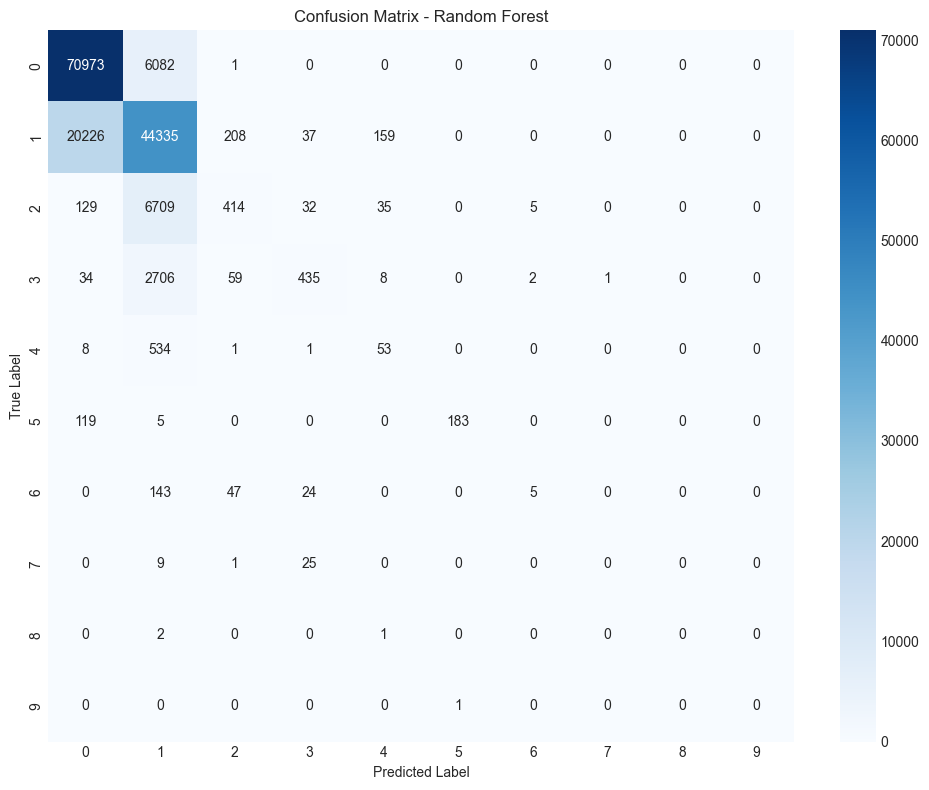


EVALUATION: Decision Tree

Accuracy:  0.6648
Precision: 0.6651
Recall:    0.6648
F1 Score:  0.6649

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.75      0.74      0.75     77056
           1       0.63      0.64      0.63     64965
           2       0.30      0.29      0.30      7324
           3       0.36      0.36      0.36      3245
           4       0.30      0.29      0.30       597
           5       0.12      0.17      0.14       307
           6       0.11      0.11      0.11       219
           7       0.07      0.09      0.08        35
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         1

    accuracy                           0.66    153752
   macro avg       0.26      0.27      0.27    153752
weighted avg       0.67      0.66      0.66    153752



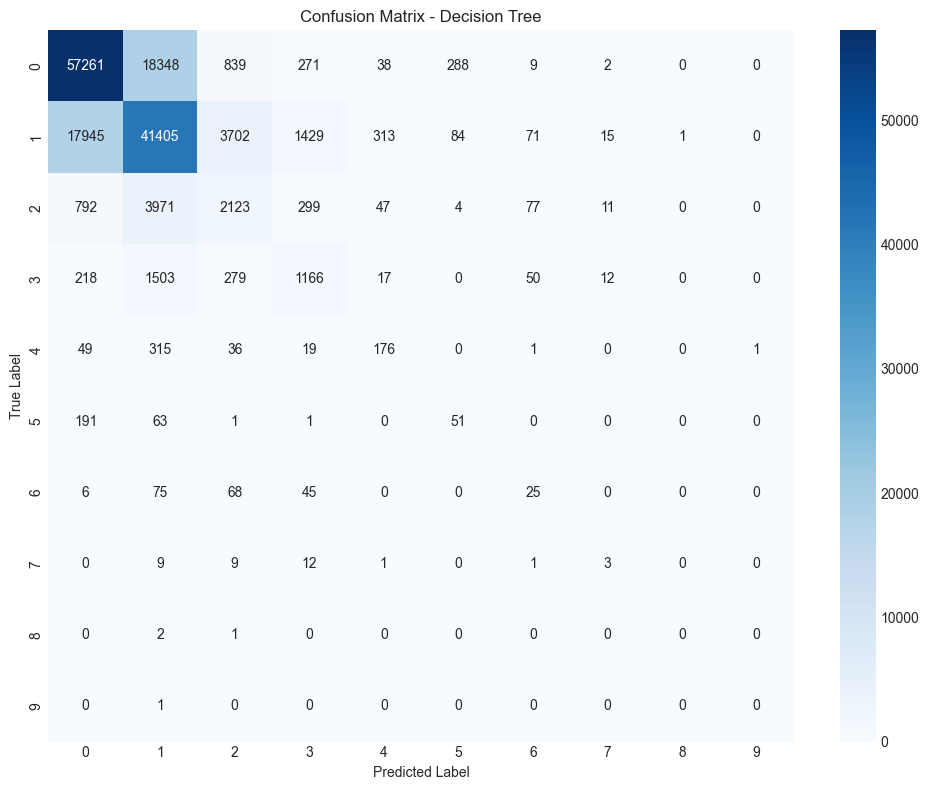


EVALUATION: Naive Bayes

Accuracy:  0.0130
Precision: 0.4467
Recall:    0.0130
F1 Score:  0.0219

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.60      0.01      0.03     77056
           1       0.34      0.01      0.02     64965
           2       0.04      0.03      0.03      7324
           3       0.02      0.01      0.01      3245
           4       0.01      0.24      0.01       597
           5       0.00      0.03      0.00       307
           6       0.00      0.07      0.00       219
           7       0.00      0.26      0.00        35
           8       0.00      0.33      0.00         3
           9       0.00      0.00      0.00         1

    accuracy                           0.01    153752
   macro avg       0.10      0.10      0.01    153752
weighted avg       0.45      0.01      0.02    153752



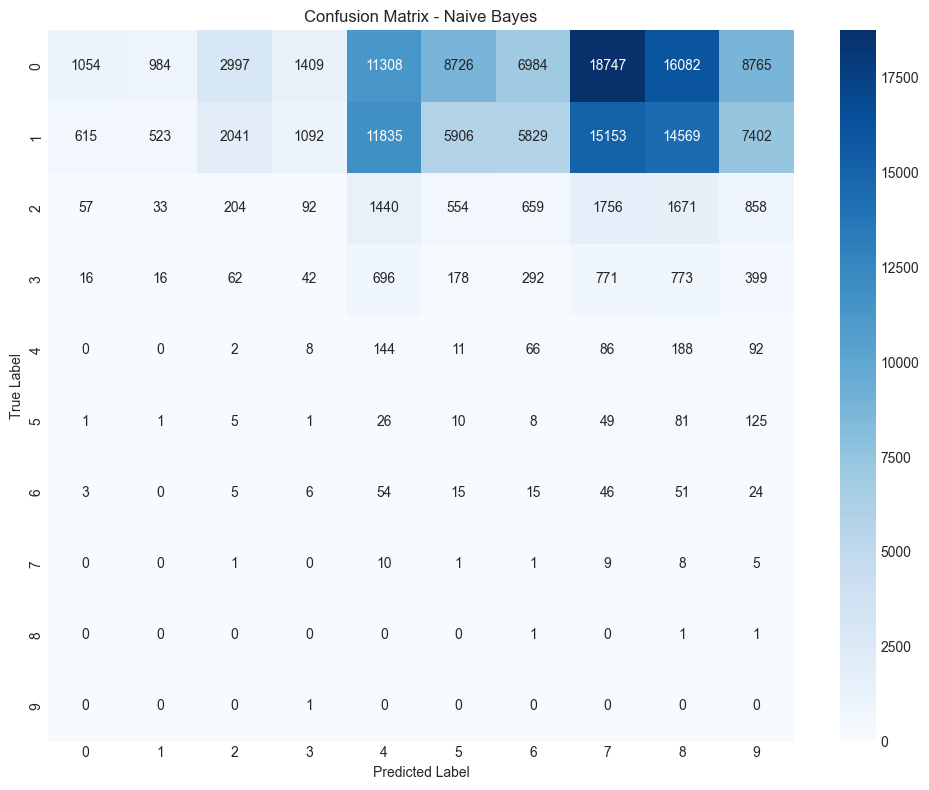


EVALUATION: Softmax Regression

Accuracy:  0.0945
Precision: 0.4616
Recall:    0.0945
F1 Score:  0.1415

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.55      0.04      0.07     77056
           1       0.43      0.17      0.24     64965
           2       0.07      0.03      0.04      7324
           3       0.02      0.11      0.04      3245
           4       0.00      0.01      0.00       597
           5       0.00      0.03      0.01       307
           6       0.00      0.02      0.00       219
           7       0.00      0.51      0.00        35
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         1

    accuracy                           0.09    153752
   macro avg       0.11      0.09      0.04    153752
weighted avg       0.46      0.09      0.14    153752



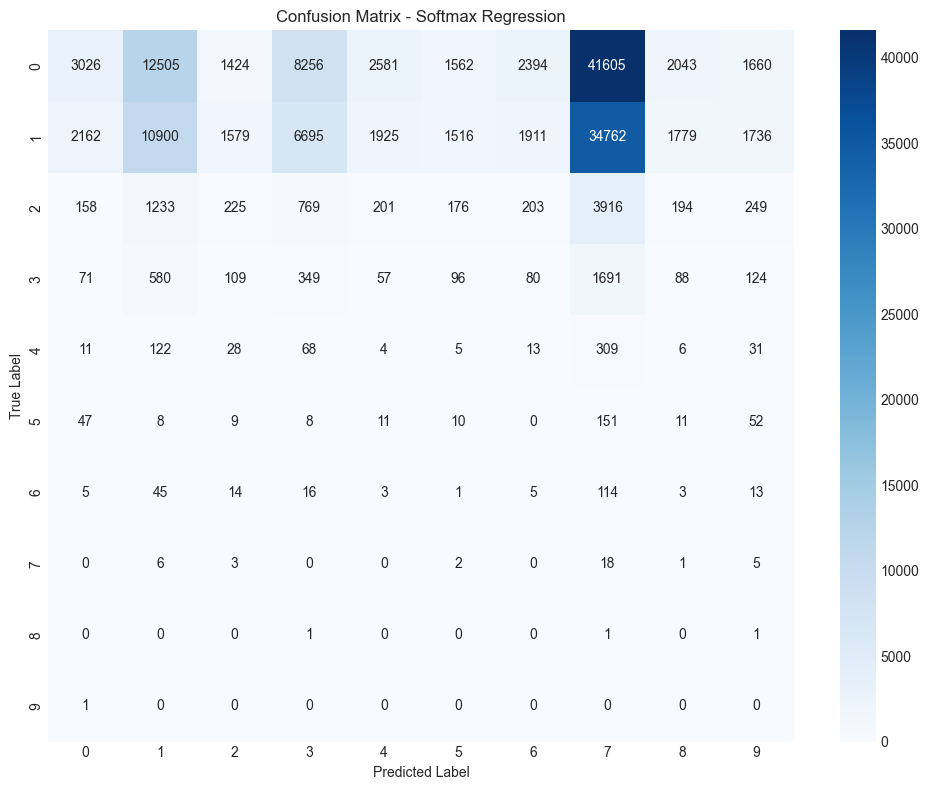

In [ ]:

print("\n" + "=" * 80)
print("PART 4: MODEL EVALUATION")
print("=" * 80)

# Function to evaluate model
def evaluate_model(model, X_test, y_test, model_name):
    print(f"\n{'=' * 80}")
    print(f"EVALUATION: {model_name}")
    print('=' * 80)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Basic metrics
    accuracy = accuracy_score(y_test, y_pred)
   # Precision, Recall, F1 are calculated with 'weighted avg' to account for imbalance
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"\nAccuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    
   # Classification report: shows metrics for each individual class
    print(f"\n--- Classification Report ---")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(10, 8))
   # Darker color indicates a higher number of samples 
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
        'y_pred': y_pred
    }

# Evaluate all models on test set
test_results = {}

for model_name, model_info in results.items():
    model = model_info['model']
    test_metrics = evaluate_model(model, X_test_scaled, y_test, model_name)
    test_results[model_name] = test_metrics


## ROC-AUC ANALYSIS (MULTICLASS)

ROC (Receiver Operating Characteristic) analysis and the AUC (Area Under the Curve) metric measure the model's discrimination capability between classes, evaluating the trade-off between True Positive Rate (Recall) and False Positive Rate.

In the multiclass context, the **micro-average AUC** is calculated, which is particularly useful for evaluating the model's overall performance in the presence of imbalance.


PART 5: ROC-AUC ANALYSIS (MULTICLASS)

Random Forest - Micro-average AUC: 0.9770

Decision Tree - Micro-average AUC: 0.8138

Naive Bayes - Micro-average AUC: 0.5876

Softmax Regression - Micro-average AUC: 0.3704


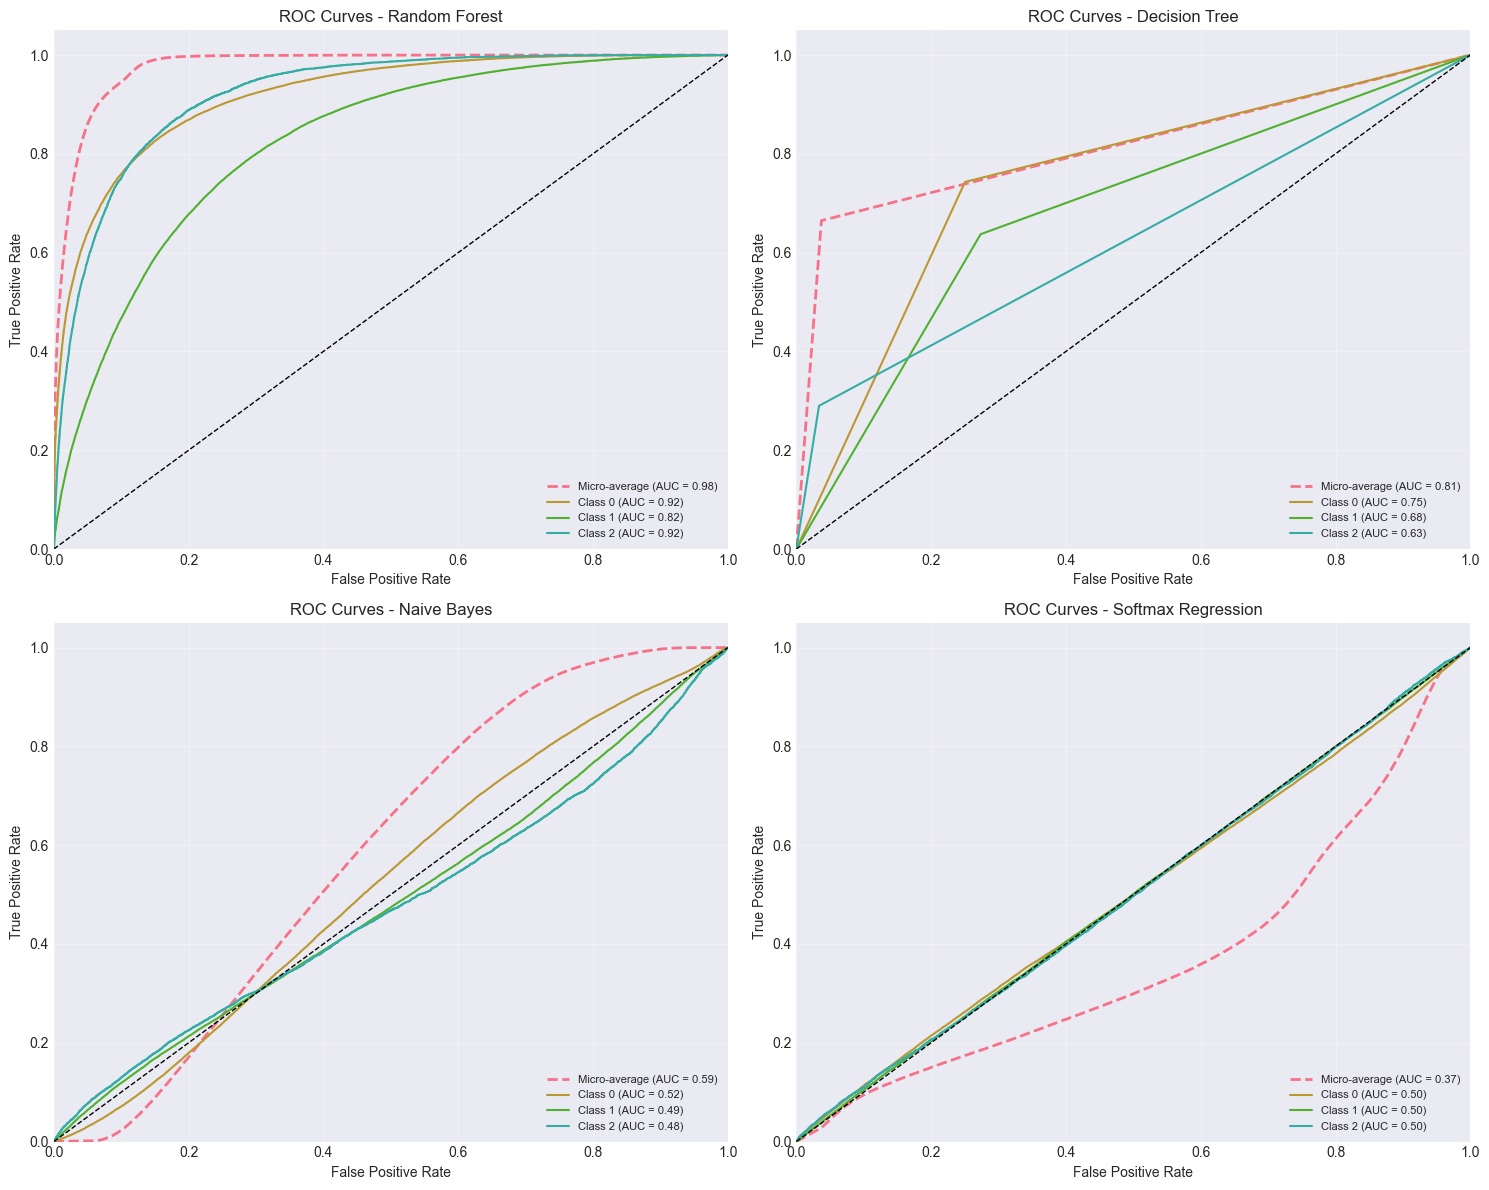

In [20]:
print("\n" + "=" * 80)
print("PART 5: ROC-AUC ANALYSIS (MULTICLASS)")
print("=" * 80)

# Binarize the output for multiclass ROC
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC area for each model
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, (model_name, model_info) in enumerate(results.items()):
    model = model_info['model']
    
    # Get probability predictions
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_scaled)
    else:
        continue
    
    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute micro-average ROC curve and AUC
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Plot
    ax = axes[idx]
    ax.plot(fpr["micro"], tpr["micro"],
            label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})',
            linewidth=2, linestyle='--')
    
    for i in range(min(3, n_classes)):  # Plot first 3 classes for clarity
        ax.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves - {model_name}')
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, alpha=0.3)
    
    print(f"\n{model_name} - Micro-average AUC: {roc_auc['micro']:.4f}")

plt.tight_layout()
plt.show()

## COMPARATIVE ANALYSIS

This section presents a comparative summary of the performance of the four models on the test set, analyzing key metrics and diagnosing potential issues like the bias-variance trade-off.

The **Weighted F1 Score** is the most representative metric for the overall performance, given the extreme **class imbalance** of the Poker Hand dataset.## COMPARATIVE ANALYSIS


PART 6: COMPARATIVE ANALYSIS

--- Model Comparison Summary ---
             Model  CV Score (Train)  Validation Accuracy  Test Accuracy  Test Precision  Test Recall  Test F1  Training Time (s)
     Random Forest          0.743605             0.754901       0.757050        0.745226     0.757050 0.732397       12085.768614
     Decision Tree          0.651245             0.664280       0.664772        0.665115     0.664772 0.664917         233.678683
       Naive Bayes          0.106653             0.013134       0.013021        0.446656     0.013021 0.021937           1.594389
Softmax Regression          0.144214             0.093106       0.094548        0.461648     0.094548 0.141462        1860.530950


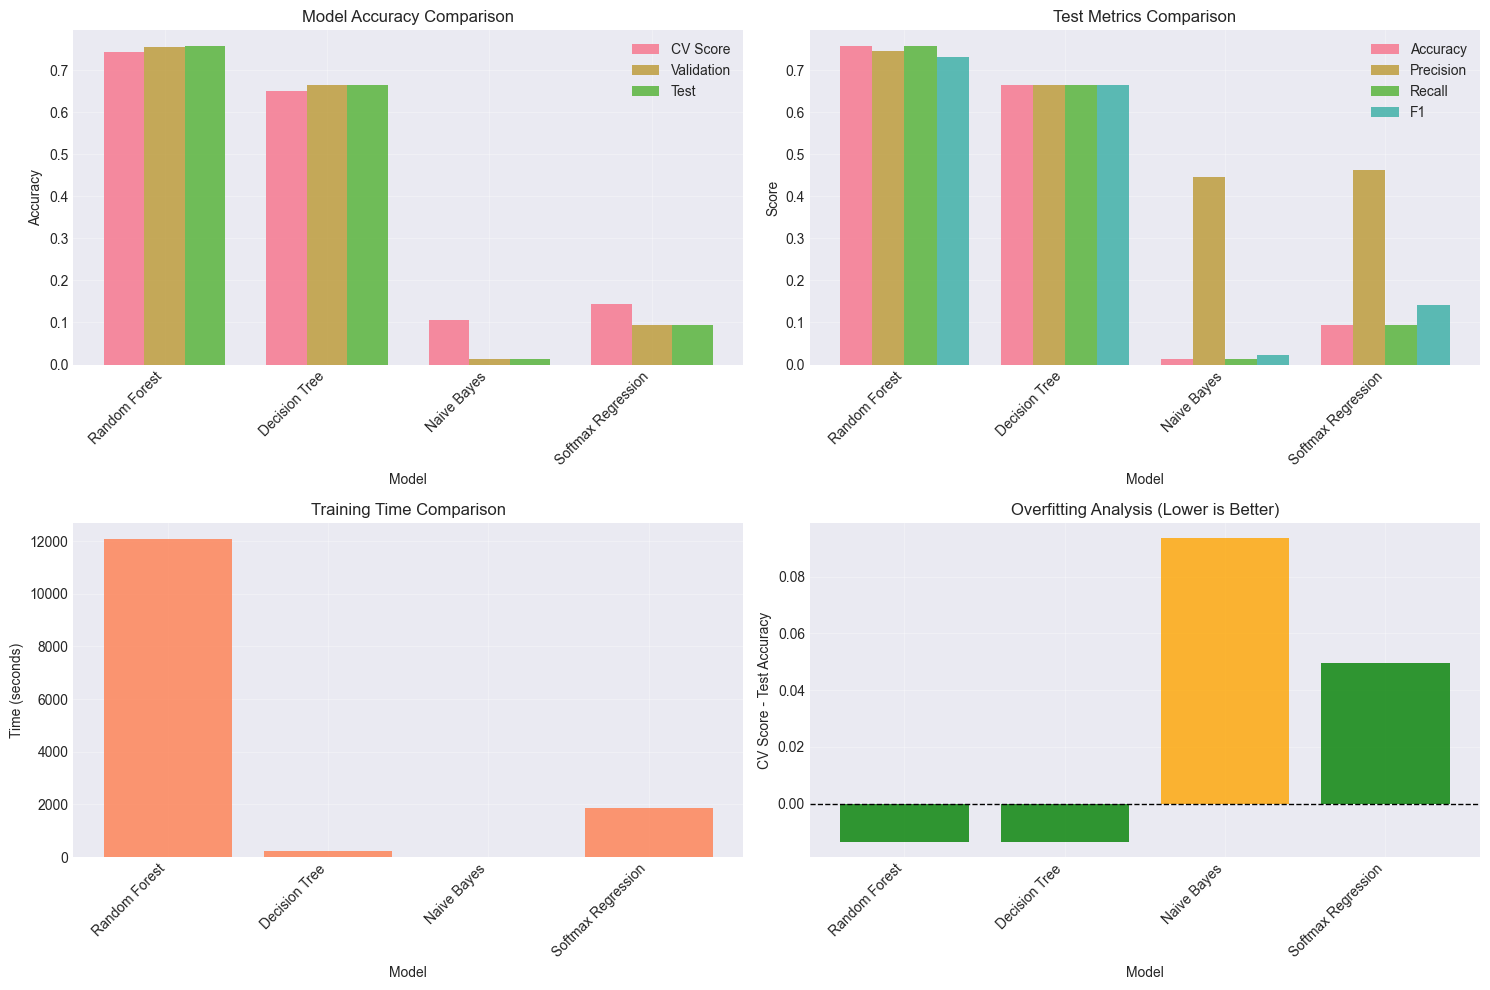

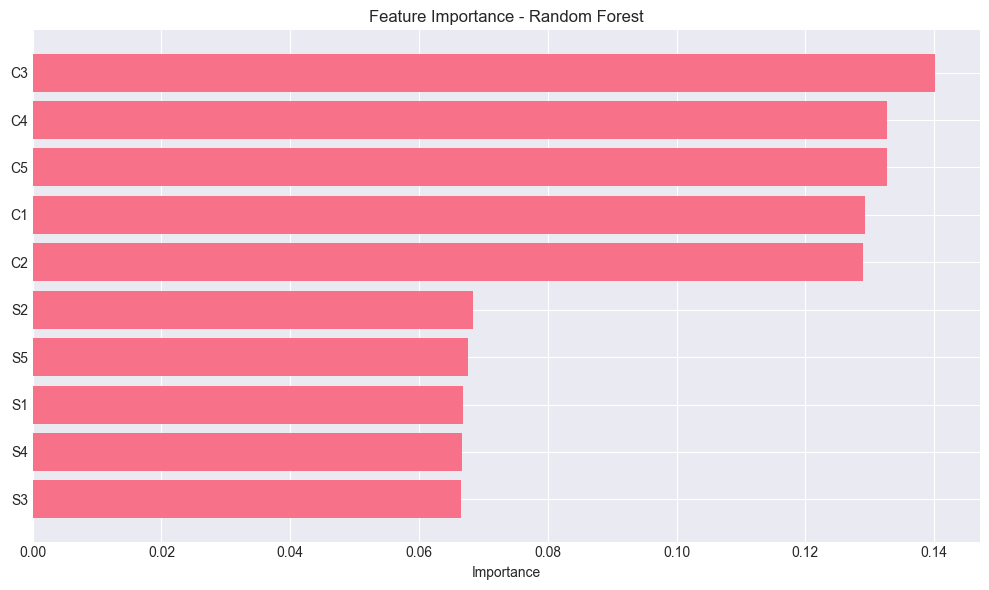

In [21]:
print("\n" + "=" * 80)
print("PART 6: COMPARATIVE ANALYSIS")
print("=" * 80)

# Create comparison dataframe
comparison_data = []
for model_name in results.keys():
    comparison_data.append({
        'Model': model_name,
        'CV Score (Train)': results[model_name]['train_score'],
        'Validation Accuracy': results[model_name]['val_accuracy'],
        'Test Accuracy': test_results[model_name]['accuracy'],
        'Test Precision': test_results[model_name]['precision'],
        'Test Recall': test_results[model_name]['recall'],
        'Test F1': test_results[model_name]['f1'],
        'Training Time (s)': results[model_name]['training_time']
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n--- Model Comparison Summary ---")
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Accuracy comparison
ax1 = axes[0, 0]
models = comparison_df['Model']
x_pos = np.arange(len(models))
width = 0.25

ax1.bar(x_pos - width, comparison_df['CV Score (Train)'], width, label='CV Score', alpha=0.8)
ax1.bar(x_pos, comparison_df['Validation Accuracy'], width, label='Validation', alpha=0.8)
ax1.bar(x_pos + width, comparison_df['Test Accuracy'], width, label='Test', alpha=0.8)

ax1.set_xlabel('Model')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Comparison')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Test metrics comparison
ax2 = axes[0, 1]
metrics = ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1']
x_pos = np.arange(len(models))
width = 0.2

for i, metric in enumerate(metrics):
    ax2.bar(x_pos + i*width - 1.5*width, comparison_df[metric], width, 
            label=metric.replace('Test ', ''), alpha=0.8)

ax2.set_xlabel('Model')
ax2.set_ylabel('Score')
ax2.set_title('Test Metrics Comparison')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Training time comparison
ax3 = axes[1, 0]
ax3.bar(models, comparison_df['Training Time (s)'], alpha=0.8, color='coral')
ax3.set_xlabel('Model')
ax3.set_ylabel('Time (seconds)')
ax3.set_title('Training Time Comparison')
ax3.set_xticklabels(models, rotation=45, ha='right')
ax3.grid(True, alpha=0.3)

# 4. Overfitting analysis (Train vs Test)
ax4 = axes[1, 1]
train_test_diff = comparison_df['CV Score (Train)'] - comparison_df['Test Accuracy']
colors = ['green' if x < 0.05 else 'orange' if x < 0.1 else 'red' for x in train_test_diff]
ax4.bar(models, train_test_diff, alpha=0.8, color=colors)
ax4.set_xlabel('Model')
ax4.set_ylabel('CV Score - Test Accuracy')
ax4.set_title('Overfitting Analysis (Lower is Better)')
ax4.set_xticklabels(models, rotation=45, ha='right')
ax4.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance visualization (Random Forest)
if 'Random Forest' in trained_models:
    plt.figure(figsize=(10, 6))
    feature_importance_sorted = feature_importance.sort_values('importance', ascending=True)
    plt.barh(range(len(feature_importance_sorted)), feature_importance_sorted['importance'])
    plt.yticks(range(len(feature_importance_sorted)), feature_importance_sorted['feature'])
    plt.xlabel('Importance')
    plt.title('Feature Importance - Random Forest')
    plt.tight_layout()
    plt.show()


## LEARNING CURVE

Learning curves show the model's performance (Accuracy) as a function of the number of training examples. They are fundamental for diagnosing:

* **High Bias (Underfitting)**: If both the training score and cross-validation score are low and converge quickly.
* **High Variance (Overfitting)**: If the training score is very high and the cross-validation score is significantly lower (large gap).
* **Convergence**: If adding more data would or would not improve the model.


PART 7: LEARNING CURVES


Python(10383) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(10384) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(10385) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(10386) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(10387) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(10388) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(10389) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(10390) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(10391) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(10392) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(10647) Malloc

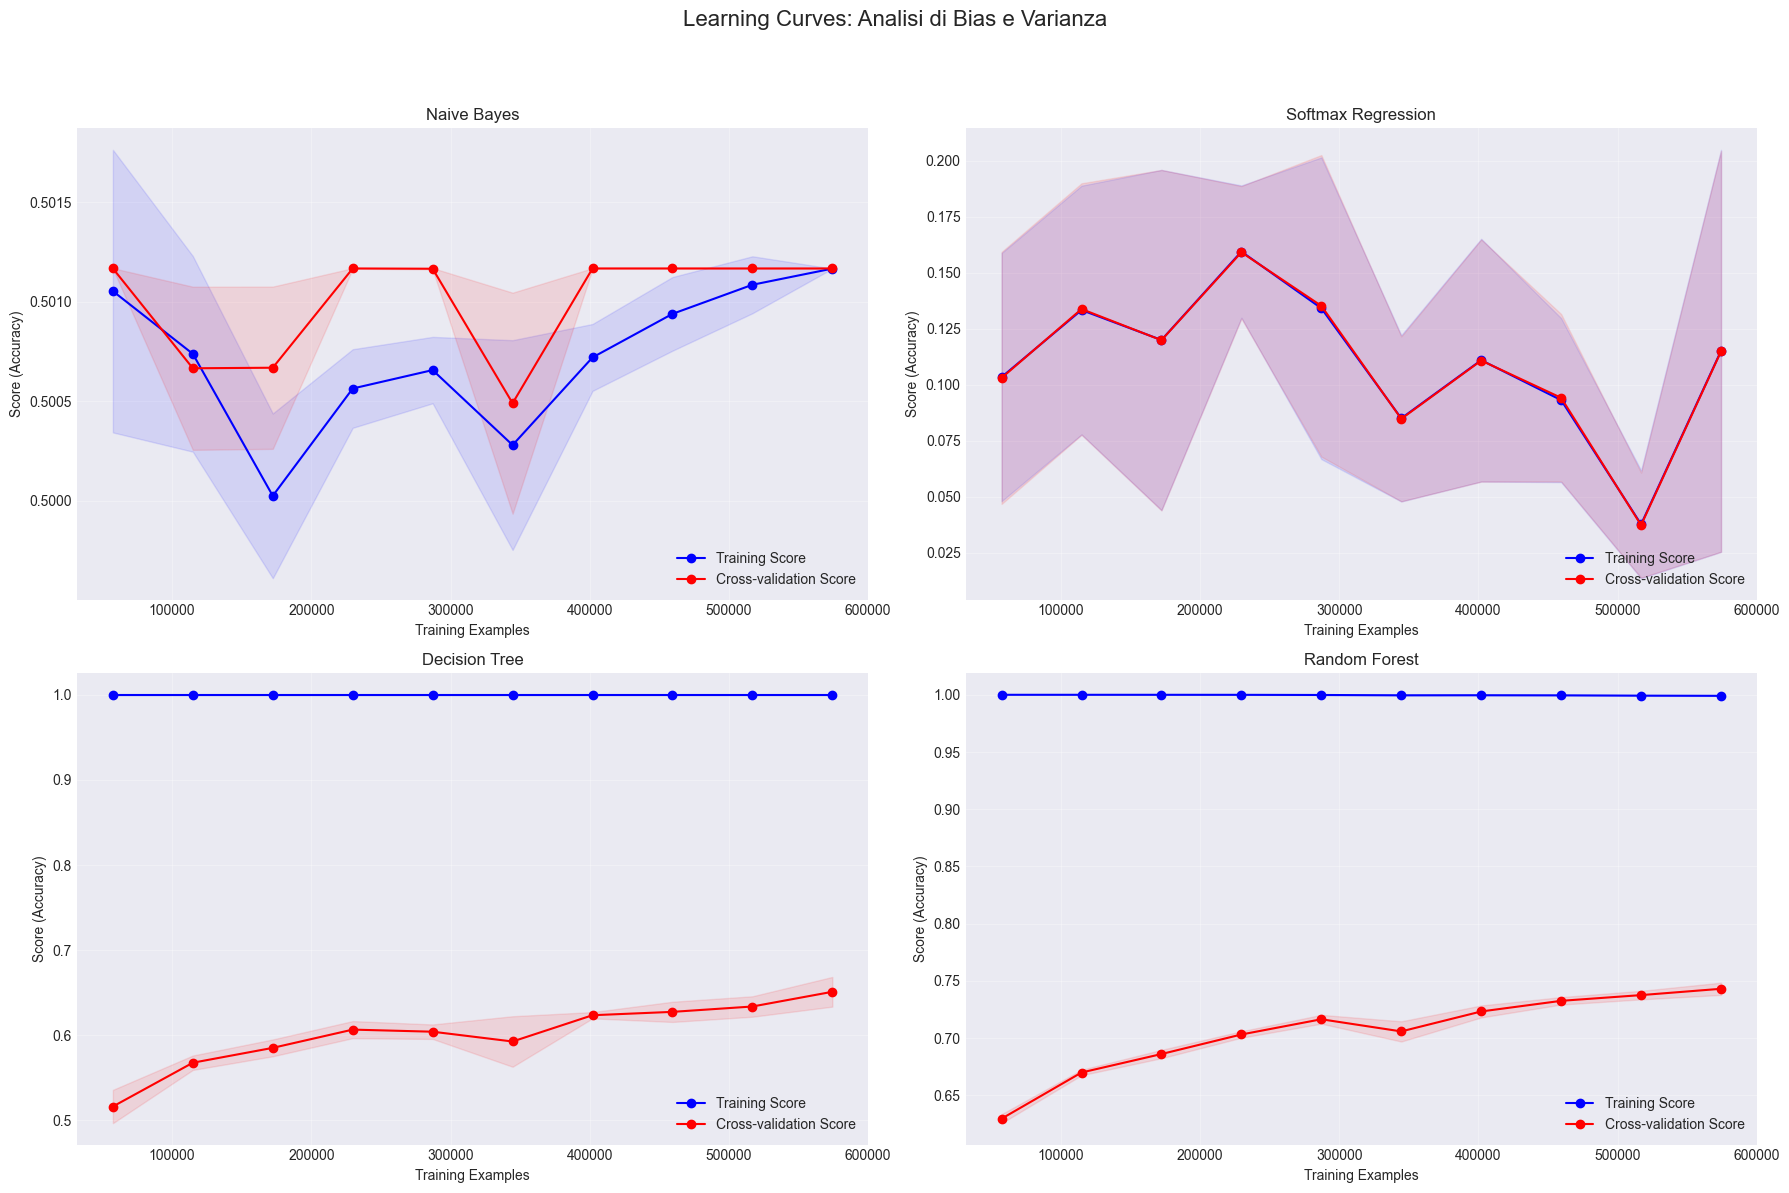

In [ ]:
## LEARNING CURVES GENERATION

from sklearn.model_selection import learning_curve

print("\n" + "=" * 80)
print("PART 7: LEARNING CURVES")
print("=" * 80)

# List of models to analyze
models_to_plot = {
    'Naive Bayes': trained_models['Naive Bayes'],
    'Softmax Regression': trained_models['Softmax Regression'],
    'Decision Tree': trained_models['Decision Tree'],
    'Random Forest': trained_models['Random Forest']
}

plt.figure(figsize=(18, 12))
plt.suptitle('Learning Curves: Analisi di Bias e Varianza', fontsize=16, y=1.02)

for i, (name, model) in enumerate(models_to_plot.items()):
    ax = plt.subplot(2, 2, i + 1)
    
    # Generating learning curves
    # Calculates the training score and cross-validation score for different subsets of the training set
    train_sizes, train_scores, test_scores = learning_curve( 
        model, 
        X_train_scaled, 
        y_train, 
        cv=cv_strategy, 
        scoring='accuracy', 
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10), # Usa 10 step da 10% a 100%
        random_state=RANDOM_STATE
    )

    # Calculating the mean and standard deviation of the scores
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    # Plotting the curves: colored areas represent the standard deviation
    ax.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="blue")
    ax.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="red")
    ax.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training Score")
    ax.plot(train_sizes, test_scores_mean, 'o-', color="red", label="Cross-validation Score")
    
    ax.set_title(name)
    ax.set_xlabel("Training Examples")
    ax.set_ylabel("Score (Accuracy)")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

## FINAL SUMMARY

This cell is the final summary of the comparative analysis, which synthesizes the main results and the conclusions drawn from the entire notebook.## FINAL SUMMARY


In [22]:

print("\n" + "=" * 80)
print("FINAL SUMMARY AND CONCLUSIONS")
print("=" * 80)

best_model_name = comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Model']
best_accuracy = comparison_df['Test Accuracy'].max()

print(f"\n🏆 Best performing model: {best_model_name}")
print(f"   Test Accuracy: {best_accuracy:.4f}")

print("\n--- Key Observations ---")
print(f"1. Model Performance:")
for _, row in comparison_df.iterrows():
    print(f"   - {row['Model']}: {row['Test Accuracy']:.4f} accuracy")

print(f"\n2. Training Efficiency:")
fastest_model = comparison_df.loc[comparison_df['Training Time (s)'].idxmin(), 'Model']
print(f"   - Fastest: {fastest_model} ({comparison_df['Training Time (s)'].min():.2f}s)")
slowest_model = comparison_df.loc[comparison_df['Training Time (s)'].idxmax(), 'Model']
print(f"   - Slowest: {slowest_model} ({comparison_df['Training Time (s)'].max():.2f}s)")

print(f"\n3. Overfitting Analysis:")
for _, row in comparison_df.iterrows():
    diff = row['CV Score (Train)'] - row['Test Accuracy']
    status = "Low" if diff < 0.05 else "Moderate" if diff < 0.1 else "High"
    print(f"   - {row['Model']}: {status} overfitting (diff: {diff:.4f})")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)
print("\nNext steps:")
print("1. Export results and visualizations for your LaTeX report")
print("2. Analyze the confusion matrices to understand misclassifications")
print("3. Consider ensemble methods or further hyperparameter tuning")
print("4. Document your findings in the technical report")
print("=" * 80)


FINAL SUMMARY AND CONCLUSIONS

🏆 Best performing model: Random Forest
   Test Accuracy: 0.7571

--- Key Observations ---
1. Model Performance:
   - Random Forest: 0.7571 accuracy
   - Decision Tree: 0.6648 accuracy
   - Naive Bayes: 0.0130 accuracy
   - Softmax Regression: 0.0945 accuracy

2. Training Efficiency:
   - Fastest: Naive Bayes (1.59s)
   - Slowest: Random Forest (12085.77s)

3. Overfitting Analysis:
   - Random Forest: Low overfitting (diff: -0.0134)
   - Decision Tree: Low overfitting (diff: -0.0135)
   - Naive Bayes: Moderate overfitting (diff: 0.0936)
   - Softmax Regression: Low overfitting (diff: 0.0497)

ANALYSIS COMPLETE!

Next steps:
1. Export results and visualizations for your LaTeX report
2. Analyze the confusion matrices to understand misclassifications
3. Consider ensemble methods or further hyperparameter tuning
4. Document your findings in the technical report
